# Resource perspective — resource drifts

How work is spread across resources. Drift types: **reassignment** (who performs an activity), **duration** (how fast a resource works), **pool_size** (resources added/removed), **workload** (case volume). Crimson lines/labels come from `rheon:metadata`.

In [6]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
LOG = ROOT / "data" / "reassigment.xes"
PERSPECTIVE = "resource"
WINDOW_DAYS = 90
NS = "{http://www.xes-standard.org/}"


def read_metadata(path):
    """Pull the rheon:metadata JSON from the log header without parsing every trace."""
    for event, elem in ET.iterparse(str(path), events=("start", "end")):
        if event == "end" and elem.tag == f"{NS}string" and elem.attrib.get("key") == "rheon:metadata":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{NS}trace":
            break
    return {}


meta = read_metadata(LOG)
drifts = [d for d in meta.get("drifts", []) if d["perspective"] == PERSPECTIVE]
for d in drifts:
    d["date"] = pd.to_datetime(d.get("drift_point_date") or d["drift_start_date"], utc=True)

pd.DataFrame([{"id": d["id"], "type": d["type"], "mode": d["mode"], "date": d["date"]}
             for d in drifts])

,id,type,mode,date
0,d01,reassignment,sudden,2020-07-01 12:00:00+00:00


In [7]:
df = pm4py.read_xes(str(LOG)).rename(columns={
    "case:concept:name": "case", "concept:name": "activity",
    "start_timestamp": "start", "time:timestamp": "end",
    "org:resource": "resource", "event:duration_min": "duration",
    "case:amount": "amount", "case:region": "region",
})
df["start"] = pd.to_datetime(df["start"], utc=True)
df["end"] = pd.to_datetime(df["end"], utc=True)
df = df.sort_values(["case", "start"]).reset_index(drop=True)
df["week"] = df["end"].dt.to_period("W").dt.start_time
df["wait_min"] = ((df["start"] - df.groupby("case")["end"].shift()).dt.total_seconds() / 60).clip(lower=0)

cases = (df.groupby("case")
         .agg(start=("start", "min"), end=("end", "max"), length=("activity", "size"),
              variant=("activity", " ".join), amount=("amount", "first"), region=("region", "first"))
         .reset_index().sort_values("start").reset_index(drop=True))
cases["week"] = cases["start"].dt.to_period("W").dt.start_time
cases["gap_min"] = cases["start"].diff().dt.total_seconds() / 60

acts = sorted(df["activity"].unique())
ress = sorted(df["resource"].dropna().unique())
ACT = dict(zip(acts, map(to_hex, sns.color_palette("Set2", max(len(acts), 1)))))
RES = dict(zip(ress, map(to_hex, sns.color_palette("tab20", max(len(ress), 1)))))


def drift_lines(ax, subset=None):
    """Mark drift change points on a time axis."""
    for d in (drifts if subset is None else subset):
        ax.axvline(d["date"], color="crimson", ls="--", lw=1, alpha=0.8)
        ax.annotate(d["id"], (d["date"], 1), xycoords=("data", "axes fraction"),
                    ha="center", va="bottom", fontsize=8, color="crimson")


def window(d, by="event", days=WINDOW_DAYS):
    """Events (by='event') or cases (by='case') just before vs after a drift, clipped to neighbours."""
    t = d["date"]
    near = [x["date"] for x in drifts if x["date"] != t]
    lo = max([t - pd.Timedelta(days=days)] + [o for o in near if o < t])
    hi = min([t + pd.Timedelta(days=days)] + [o for o in near if o > t])
    if by == "case":
        return (cases[(cases["start"] >= lo) & (cases["start"] < t)],
                cases[(cases["start"] >= t) & (cases["start"] < hi)])
    return df[(df["end"] >= lo) & (df["end"] < t)], df[(df["end"] >= t) & (df["end"] < hi)]

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19854/19854 [00:01<00:00, 12023.81it/s]
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_38819/1234163824.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["end"].dt.to_period("W").dt.start_time
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_38819/1234163824.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cases["week"] = cases["start"].dt.to_period("W").dt.start_time


In [8]:
def res_bars(ax, pre, post, fn, ylabel, highlight=()):
    sp, sq = fn(pre).reindex(ress, fill_value=0), fn(post).reindex(ress, fill_value=0)
    x = np.arange(len(ress))
    ax.bar(x - 0.2, sp.values, 0.4, label="pre", color=["#08519c" if r in highlight else "#bdd7e7" for r in ress])
    ax.bar(x + 0.2, sq.values, 0.4, label="post", color=["#a50f15" if r in highlight else "#fcae91" for r in ress])
    ax.set_xticks(x); ax.set_xticklabels(ress, rotation=45, ha="right"); ax.set_ylabel(ylabel); ax.legend()


def res_act(sub):
    return pd.crosstab(sub["resource"], sub["activity"]).reindex(index=ress, columns=acts, fill_value=0)

## Overview

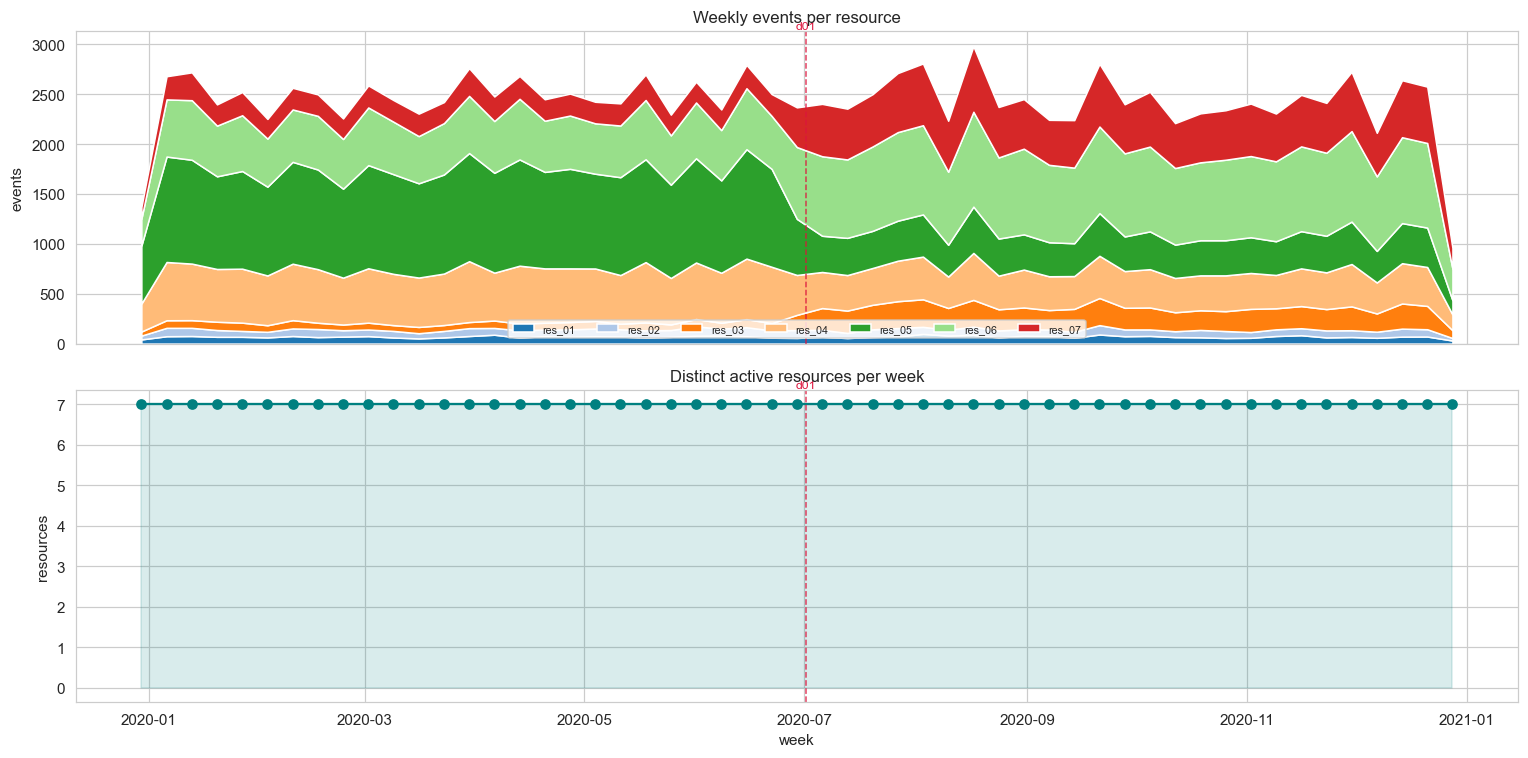

In [9]:
we = df.groupby(["week", "resource"]).size().unstack(fill_value=0).reindex(columns=ress, fill_value=0)
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].stackplot(we.index, we.T.values, labels=ress, colors=[RES[r] for r in ress])
ax[0].set(title="Weekly events per resource", ylabel="events")
ax[0].legend(ncol=len(ress), fontsize=7, loc="lower center"); drift_lines(ax[0])
active = df.groupby("week")["resource"].nunique()
ax[1].plot(active.index, active.values, marker="o", color="teal")
ax[1].fill_between(active.index, active.values, alpha=.15, color="teal")
ax[1].set(title="Distinct active resources per week", xlabel="week", ylabel="resources"); drift_lines(ax[1])
plt.tight_layout(); plt.show()

## Before vs after each drift

Each drift gets the views that expose its signal.

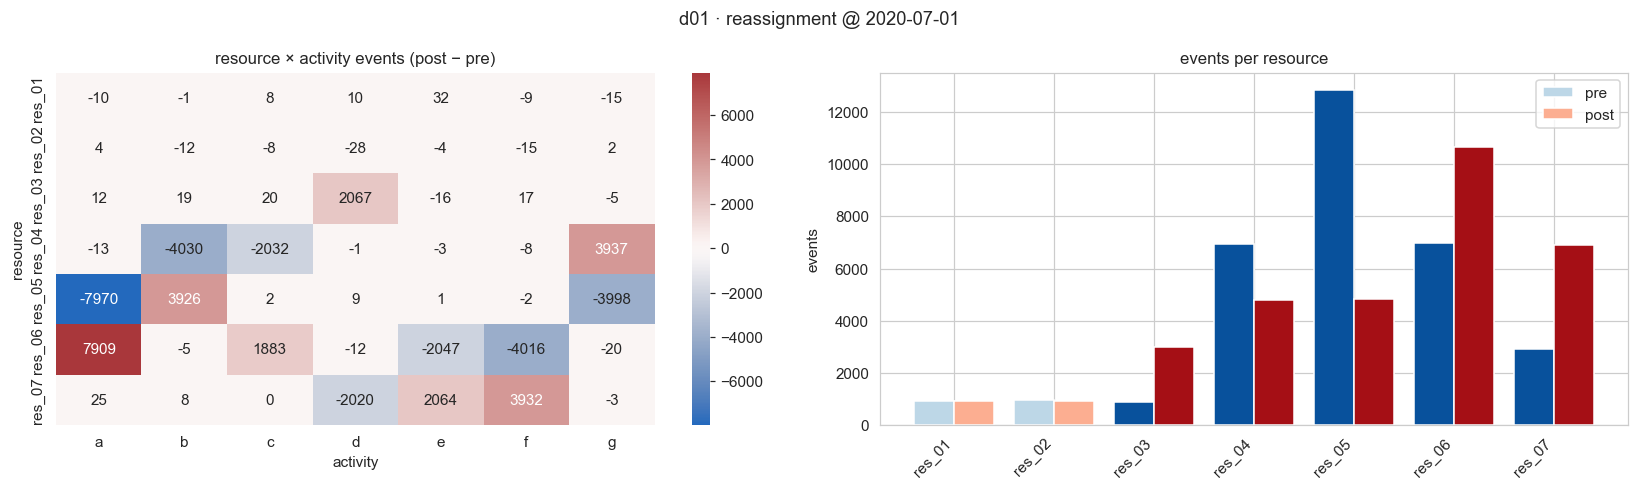

In [10]:
for d in drifts:
    c, t = d["changes"], d["type"]
    pre, post = window(d, by="event")
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

    if t == "reassignment":
        moved = {r for a in acts if c["dominant_before"].get(a) != c["dominant_after"].get(a)
                 for r in (c["dominant_before"].get(a), c["dominant_after"].get(a)) if r}
        fig.suptitle(f"{d['id']} \u00b7 reassignment @ {d['date']:%Y-%m-%d}")
        sns.heatmap(res_act(post) - res_act(pre), annot=True, fmt="d", cmap="vlag", center=0, ax=ax[0])
        ax[0].set(title="resource \u00d7 activity events (post \u2212 pre)", xlabel="activity", ylabel="resource")
        res_bars(ax[1], pre, post, lambda s: s["resource"].value_counts(), "events", highlight=moved)
        ax[1].set_title("events per resource")

    elif t == "duration":
        aff = set(c["affected_resources"])
        fig.suptitle(f"{d['id']} \u00b7 duration \u00d7{c['factor']} @ {d['date']:%Y-%m-%d}")
        w = df.groupby(["week", "resource"])["duration"].mean().unstack().reindex(columns=ress)
        for r in ress:
            ax[0].plot(w.index, w[r], color=RES[r], lw=2.6 if r in aff else 1,
                       alpha=1 if r in aff else .3, label=r if r in aff else None)
        ax[0].set(title="weekly mean duration (min)", xlabel="week", ylabel="min")
        ax[0].legend(title="affected", fontsize=8); drift_lines(ax[0], [d])
        res_bars(ax[1], pre, post, lambda s: s.groupby("resource")["duration"].mean(), "mean min", highlight=aff)
        ax[1].set_title("mean duration per resource")

    elif t == "pool_size":
        moved = set(c.get("removed_resources", []) + c.get("added_resources", []))
        fig.suptitle(f"{d['id']} \u00b7 pool_size {c.get('old_pool_size')} \u2192 {c.get('new_pool_size')} @ {d['date']:%Y-%m-%d}")
        active = df.groupby("week")["resource"].nunique()
        ax[0].plot(active.index, active.values, marker="o", color="teal")
        ax[0].fill_between(active.index, active.values, alpha=.15, color="teal")
        ax[0].set(title="distinct active resources / week", xlabel="week", ylabel="resources"); drift_lines(ax[0], [d])
        res_bars(ax[1], pre, post, lambda s: s["resource"].value_counts(), "events", highlight=moved)
        ax[1].set_title("events per resource")

    elif t == "workload":
        fig.suptitle(f"{d['id']} \u00b7 workload \u00d7{c.get('workload_factor')} @ {d['date']:%Y-%m-%d}")
        cw = cases.groupby("week").size()
        ax[0].bar(cw.index, cw.values, width=5, color="#3182bd")
        ax[0].set(title="cases started / week", xlabel="week", ylabel="cases"); drift_lines(ax[0], [d])
        res_bars(ax[1], pre, post, lambda s: s["resource"].value_counts(), "events")
        ax[1].set_title("events per resource")

    plt.tight_layout(); plt.show()